The sandbox contains test code and can be safely ignored.

/tmp/ipykernel_245623/1140337221.py:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd
Matplotlib created a temporary cache directory at /tmp/matplotlib-4lb4w4cn because the default path (/prod/zue/fc_development/users/atr/cache/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.
/tmp/ipykernel_245623/1140337221.py:8: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  timestamps = 

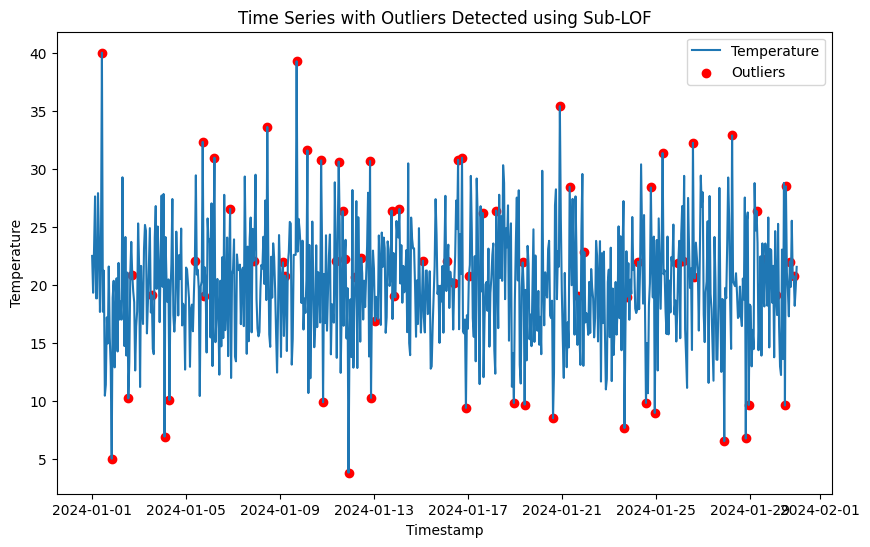

In [1]:
import numpy as np
import pandas as pd
from sklearn.neighbors import LocalOutlierFactor
import matplotlib.pyplot as plt

# Generate a sample time series temperature dataset
np.random.seed(42)
timestamps = pd.date_range(start="2024-01-01", end="2024-01-31", freq="H")
temperatures = np.random.normal(loc=20, scale=5, size=len(timestamps))

# Introduce some outliers
temperatures[10] = 40
temperatures[20] = 5

# Create a DataFrame
df = pd.DataFrame({"Timestamp": timestamps, "Temperature": temperatures})

# Extract temperature values as a 1D array
temperature_values = df["Temperature"].values.reshape(-1, 1)

# Use the Sub-LOF method to detect outliers
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.1)
outliers = lof.fit_predict(temperature_values)

# Add the outlier labels to the DataFrame
df["Outlier"] = outliers

# Plot the time series with outliers highlighted
plt.figure(figsize=(10, 6))
plt.plot(df["Timestamp"], df["Temperature"], label="Temperature")
plt.scatter(df["Timestamp"][df["Outlier"] == -1], df["Temperature"][df["Outlier"] == -1], color='red', label="Outliers")
plt.title("Time Series with Outliers Detected using Sub-LOF")
plt.xlabel("Timestamp")
plt.ylabel("Temperature")
plt.legend()
plt.show()


In [ ]:
import re
import time

pattern = r"tei49c-\d{12}.(zip|dat)"

path = "/product_data/data/pay/Kenya/git/gaw-kenya/data/tei49c-202306160050.zip"

res = re.search(pattern, path).group()
print(res)

In [ ]:
import os
import shutil

root = "/product_data/data/pay/Kenya/MKN/incoming/meteo"

for path, dirs, files in os.walk(root):
    for file in files:
        source = os.path.join(path, file)

        try:
            if not ".zip" in source:
                with open(file=source, mode="r") as fh:
                    str = fh.readlines()[4].split(" ")[1]

                target = os.path.join(root, str[0:4], str[4:6], str[6:8], file)
                if source != target:
                    print(f"{source} > {target}")
                    shutil.move(src=source, dst=target)
        except Exception as err:
            print(f"Failed to read file: {source}")

In [ ]:
import os
source = os.path.join("/product_data/data/pay/Kenya/MKN/incoming/g2401")
by = "month" # "year"
years = ["20{:2d}".format(yy) for yy in range(20, 30, 1)]
months = ["{:02d}".format(mm) for mm in range(1, 13, 1)]

for year in years:
    if by=="month":
        for month in months:
            base = os.path.join(source, year, month)        
            if os.path.exists(base):
                for root, dirs, files in os.walk(base):
                    print(f"base: {base}")                
                    print(f"root: {root}")
                    print(f"files: {len(files)}")
    elif by=="year":
        base = os.path.join(source, year)        
        if os.path.exists(base):
            for root, dirs, files in os.walk(base):
                print(f"base: {base}")                
                print(f"root: {root}")
                print(f"files: {len(files)}")


In [ ]:
["20{:2d}".format(yy) for yy in range(20, 30, 1)]

In [ ]:
# # Concatenate the individual DataFrames into a single one
# combined_data = pl.concat(dataframes)

# # Assuming you have datetime columns, replace 'datetime_column' with the actual column name.
# datetime_column = 'timestamp'

# # Perform aggregation by datetime_column
# agg_data = (
#     combined_data
#     .with_column(combined_data[datetime_column].cast(pl.Date32))
#     .groupby(datetime_column)
#     .agg(pl.sum(combined_data['value_column']))
#     .sort(datetime_column)
# )

In [ ]:
# Example of using ECOD for outlier detection
# Author: Yue Zhao <zhaoy@cmu.edu>
# License: BSD 2 clause
# adapted from: https://github.com/yzhao062/pyod/blob/master/examples/ecod_example.py

from __future__ import division
from __future__ import print_function

import os
import sys

# temporary solution for relative imports in case pyod is not installed
# if pyod is installed, no need to use the following line
# sys.path.append(
#     os.path.abspath(os.path.join(os.path.dirname("__file__"), '..')))

from pyod.models.ecod import ECOD
from pyod.utils.data import generate_data
from pyod.utils.data import evaluate_print
from pyod.utils.example import visualize

contamination = 0.1  # percentage of outliers
n_train = 200  # number of training points
n_test = 100  # number of testing points

# Generate sample data
X_train, X_test, y_train, y_test = \
    generate_data(n_train=n_train,
                    n_test=n_test,
                    n_features=2,
                    contamination=contamination,
                    random_state=42)

# train ECOD detector
clf_name = 'ECOD'
# clf = ECOD()

# you could try parallel version as well.
clf = ECOD(n_jobs=2)
clf.fit(X_train)

# get the prediction labels and outlier scores of the training data
y_train_pred = clf.labels_  # binary labels (0: inliers, 1: outliers)
y_train_scores = clf.decision_scores_  # raw outlier scores

# get the prediction on the test data
y_test_pred = clf.predict(X_test)  # outlier labels (0 or 1)
y_test_scores = clf.decision_function(X_test)  # outlier scores

# evaluate and print the results
print("\nOn Training Data:")
evaluate_print(clf_name, y_train, y_train_scores)
print("\nOn Test Data:")
evaluate_print(clf_name, y_test, y_test_scores)

# visualize the results
visualize(clf_name, X_train, y_train, X_test, y_test, y_train_pred,
            y_test_pred, show_figure=True, save_figure=False)